# Pipeline complet Deribit — BTC options de bout en bout

Ce notebook descend toute la pile de la plateforme, couche par couche, sur des **vraies options BTC
Deribit** (API publique, aucune authentification requise) :

```
Connexion  →  Discovery  →  Snapshot  →  Forwards  →  IV  →  Surface SVI  →  Pricing  →  Risk  →  Scénarios
```

**Mode `LIVE_DATA = True` (défaut)** — appelle l'API Deribit en temps réel.  
**Mode `LIVE_DATA = False`** — utilise des fixtures synthétiques BTC-like si Deribit est inaccessible.

Chaque cellule est indépendante : elle appelle uniquement les engines testés et n'ajoute aucune
logique métier ici.

Run : `uv run --group notebooks jupyter lab notebooks/demo_pipeline_deribit.ipynb`

In [113]:
# %% Setup — imports, chemins, flag live/synthetic
from __future__ import annotations

from datetime import UTC, datetime, timedelta
from decimal import Decimal
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Infra core engines
from algotrading.core.config import load_config
from algotrading.infra.forwards import ForwardParams, build_forward_curve
from algotrading.infra.iv import IvParams, solve_chain
from algotrading.infra.pricing import OptionStyle, PricingInput, PricingParams, price
from algotrading.infra.risk import (
    InstrumentAnalytics,
    Position,
    PositionSet,
    Scenario,
    ScenarioGrid,
    aggregate_risk,
    by_underlying,
    compute_risk_lines,
    run_grid,
)
from algotrading.infra.snapshots import MarketStateSnapshot, SnapshotParams, build_snapshot
from algotrading.infra.storage.events import RawMarketEvent
from algotrading.infra.surfaces import SurfaceConfig, build_surface
from algotrading.infra.surfaces.engine import SurfaceResult
from algotrading.infra.universe.contracts import OptionContract, Right, Underlying, instrument_key
from algotrading.infra.utils.daycount import DayCountConvention

# Infra-Deribit
from algotrading.infra_deribit.collectors.deribit_discovery import discover_instruments
from algotrading.infra_deribit.connectivity.deribit_transport import DeribitTransport


# ── Localisation du repo ─────────────────────────────────────────────────────
def _repo_root() -> Path:
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "pyproject.toml").exists() and (p / "packages").is_dir():
            return p
    raise FileNotFoundError("repo root non trouvé (pyproject.toml + packages/)")


REPO = _repo_root()
CONFIGS = REPO / "packages" / "infra" / "configs"
DERIBIT_CONFIGS = REPO / "packages" / "infra-deribit" / "configs"

# ── Paramètre global ──────────────────────────────────────────────────────────
LIVE_DATA = True  # False → fixtures synthétiques (toujours reproductible)
CURRENCY = "BTC"  # BTC ou ETH
MIN_DTE = 7  # jours minimum jusqu'à expiry
MAX_DTE = 120  # jours maximum

print(f"Repo : {REPO}")
print(f"Mode  : {'LIVE Deribit' if LIVE_DATA else 'SYNTHETIC fixtures'}")
print(f"Cible : {CURRENCY} options, {MIN_DTE}–{MAX_DTE} DTE")

Repo : c:\Users\Vincent\GitHub\Vincent-20-100\AlgoTrading
Mode  : LIVE Deribit
Cible : BTC options, 7–120 DTE


## 1 · Connexion Deribit & prix index

`DeribitTransport` est la couche réseau la plus basse — uniquement REST synchrone ici (le WebSocket
est réservé à la capture live continue). On vérifie la connectivité en récupérant le prix spot BTC/USD
via le point d'entrée public `/public/get_index_price`.

In [114]:
# %% Connexion + prix index
INDEX_NAME = f"{CURRENCY.lower()}_usd"

if LIVE_DATA:
    transport = DeribitTransport()
    index_data = transport.get("/public/get_index_price", {"index_name": INDEX_NAME})
    INDEX_PRICE: float = float(index_data["index_price"])
    print(f"✓ Connecté à Deribit — {CURRENCY}/USD index : ${INDEX_PRICE:,.0f}")
else:
    transport = None
    INDEX_PRICE = 65_000.0  # fixture synthétique
    print(f"✓ Mode synthétique — {CURRENCY}/USD fictif : ${INDEX_PRICE:,.0f}")

✓ Connecté à Deribit — BTC/USD index : $63,940


## 2 · Découverte des instruments

`discover_instruments` appelle `/public/get_instruments`, parse chaque nom Deribit
(ex. `BTC-27JUN25-100000-C`) vers un `OptionContract` canonique, et filtre par fenêtre de maturité.
Les noms malformés sont loggués et ignorés — la découverte n'avorte jamais sur un contrat défectueux.

In [115]:
# %% Découverte instruments
from collections import defaultdict
from datetime import date

if LIVE_DATA:
    contracts = discover_instruments(transport, CURRENCY, min_days=MIN_DTE, max_days=MAX_DTE)
else:
    # Fixtures synthétiques — strikes ±40% autour du spot
    today = date.today()
    expiries_synth = [
        today + timedelta(days=30),
        today + timedelta(days=60),
        today + timedelta(days=90),
    ]
    strikes_synth = [int(INDEX_PRICE * m) for m in [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]]
    contracts = [
        OptionContract(
            symbol=CURRENCY,
            expiry=exp,
            strike=Decimal(str(k)),
            right=Right(r),
            multiplier=1,
            exchange="DERIBIT",
            currency="USD",
        )
        for exp in expiries_synth
        for k in strikes_synth
        for r in ("C", "P")
    ]

print(f"Instruments découverts : {len(contracts)}")

by_expiry_map: dict[date, list[OptionContract]] = defaultdict(list)
for c in contracts:
    by_expiry_map[c.expiry].append(c)

expiries_sorted = sorted(by_expiry_map)
print(f"Expiries disponibles ({len(expiries_sorted)}) :")
for exp in expiries_sorted:
    dte = (exp - date.today()).days
    print(f"  {exp}  ({dte:3d} DTE)  —  {len(by_expiry_map[exp])} contrats")

{"ts": "2026-06-04T07:43:26.834492+00:00", "level": "INFO", "logger": "algotrading.infra_deribit.collectors.deribit_discovery", "message": "deribit_discovery_done", "currency": "BTC", "discovered": 554, "skipped": 0, "min_days": 7, "max_days": 120}


Instruments découverts : 554
Expiries disponibles (6) :
  2026-06-12  (  8 DTE)  —  66 contrats
  2026-06-19  ( 15 DTE)  —  56 contrats
  2026-06-26  ( 22 DTE)  —  118 contrats
  2026-07-31  ( 57 DTE)  —  106 contrats
  2026-08-28  ( 85 DTE)  —  92 contrats
  2026-09-25  (113 DTE)  —  116 contrats


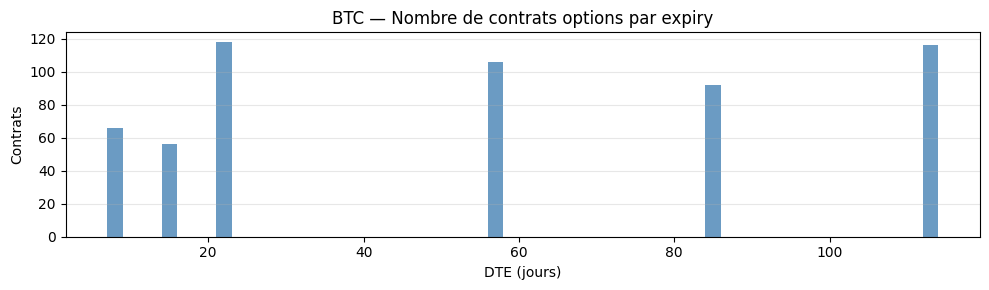

In [116]:
# %% Plot : distribution des contrats par DTE
dtes = [(exp - date.today()).days for exp in expiries_sorted]
counts = [len(by_expiry_map[exp]) for exp in expiries_sorted]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(dtes, counts, width=max(1, max(dtes) // 40), color="steelblue", alpha=0.8)
ax.set(
    xlabel="DTE (jours)",
    ylabel="Contrats",
    title=f"{CURRENCY} — Nombre de contrats options par expiry",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 3 · Collecte des quotes REST → Snapshot

Pour chaque contrat sélectionné on appelle `/public/ticker`, on convertit les prix de la devise base
(BTC) en USD (`prix_btc × index_price`), et on construit les `RawMarketEvent` (couche EAV : une
observation = un champ). `build_snapshot` assemble le `MarketStateSnapshot` point-en-temps.

> **Pourquoi REST et non WebSocket ?** Un notebook n'a pas de boucle `asyncio` permanente. Le
> WebSocket est réservé à la capture continue (`RawCollector`). Pour un snapshot ponctuel, REST
> suffit et simplifie l'exécution cellule par cellule.

In [117]:
# %% Sélection des expiries à capturer (3 premières pour rester sous le rate limit)
N_EXPIRIES = min(3, len(expiries_sorted))
selected_expiries = expiries_sorted[:N_EXPIRIES]
selected_contracts = [c for c in contracts if c.expiry in set(selected_expiries)]
print(f"Expiries sélectionnées : {selected_expiries}")
print(f"Contrats à quoter      : {len(selected_contracts)}")

Expiries sélectionnées : [datetime.date(2026, 6, 12), datetime.date(2026, 6, 19), datetime.date(2026, 6, 26)]
Contrats à quoter      : 240


In [118]:
# %% Fetch des tickers + construction des RawMarketEvent
import math

SESSION_ID = f"notebook-deribit-{datetime.now(UTC).strftime('%Y%m%d%H%M%S')}"
AS_OF = datetime.now(UTC)
events: list[RawMarketEvent] = []
_eid = 0

# Deribit ticker price fields (base currency on the wire) -> canonical EAV field names.
_DERIBIT_FIELDS = {
    "best_bid_price": "bid",
    "best_ask_price": "ask",
    "last_price": "last",
    "mark_price": "mark_price",
}


def _eid_next() -> str:
    global _eid
    _eid += 1
    return str(_eid)


def _event(instrument_key_str: str, field: str, value: float | None) -> RawMarketEvent:
    return RawMarketEvent(
        collector_session_id=SESSION_ID,
        event_id=_eid_next(),
        receipt_ts=AS_OF,
        instrument_key=instrument_key_str,
        field_name=field,
        field_value=Decimal(str(value)) if value is not None else None,
        underlying=CURRENCY,
    )


# Underlying : l'index sert de cours de reference (emis en `last` => fallback labellise).
btc_underlying = Underlying(
    symbol=CURRENCY, security_type="CRYPTO", exchange="DERIBIT", currency="USD"
)
btc_key = instrument_key(btc_underlying)
spread_half = INDEX_PRICE * 0.0001
for field, val in [
    ("bid", INDEX_PRICE - spread_half),
    ("ask", INDEX_PRICE + spread_half),
    ("last", INDEX_PRICE),
]:
    events.append(_event(btc_key, field, val))


def _deribit_name(c: OptionContract) -> str:
    """e.g. BTC-4JUN26-65000-C - Deribit uses NO leading zero on single-digit days."""
    expiry_s = f"{c.expiry.day}{c.expiry.strftime('%b%y').upper()}"
    strike_s = str(int(c.strike)) if c.strike == c.strike.to_integral_value() else str(c.strike)
    return f"{c.symbol}-{expiry_s}-{strike_s}-{c.right.value}"


def _synthetic_ticker(c: OptionContract, spot: float) -> dict:
    """Synthetic Deribit-shaped ticker (offline mode): prices in BTC, real Deribit field names."""
    from scipy.stats import norm  # type: ignore[import-untyped]

    k = float(c.strike)
    t_yr = (c.expiry - date.today()).days / 365.0
    moneyness = k / spot
    iv = 0.70 + 0.15 * max(0.0, math.log(1 / moneyness)) + 0.05 * (moneyness - 1) ** 2
    if t_yr <= 0:
        return {
            "best_bid_price": None,
            "best_ask_price": None,
            "last_price": None,
            "mark_price": None,
            "mark_iv": iv * 100,
        }
    fwd = spot  # proxy : forward = spot (r ~ 0 pour le synthetique)
    d1 = (math.log(fwd / k) + 0.5 * iv**2 * t_yr) / (iv * math.sqrt(t_yr))
    d2 = d1 - iv * math.sqrt(t_yr)
    px = (
        (fwd * norm.cdf(d1) - k * norm.cdf(d2))
        if c.right == Right.CALL
        else (k * norm.cdf(-d2) - fwd * norm.cdf(-d1))
    )
    px_btc = px / spot
    spread = max(0.0001, px_btc * 0.05)
    return {
        "best_bid_price": max(0.0001, px_btc - spread / 2),
        "best_ask_price": px_btc + spread / 2,
        "last_price": px_btc,
        "mark_price": px_btc,
        "mark_iv": iv * 100,
    }


n_fetched, n_skipped = 0, 0
for c in selected_contracts:
    opt_key = instrument_key(c)
    if LIVE_DATA:
        try:
            ticker = transport.get("/public/ticker", {"instrument_name": _deribit_name(c)})
        except Exception as exc:  # noqa: BLE001 - one bad instrument must not abort the loop
            print(f"  skip {_deribit_name(c)}: {exc}")
            n_skipped += 1
            continue
    else:
        ticker = _synthetic_ticker(c, INDEX_PRICE)

    # Deribit option prices are in BTC -> multiply by the USD index; round to the storage scale.
    for src, canon in _DERIBIT_FIELDS.items():
        raw = ticker.get(src)
        events.append(
            _event(opt_key, canon, round(float(raw) * INDEX_PRICE, 6) if raw is not None else None)
        )
    raw_iv = ticker.get("mark_iv")
    if raw_iv is not None:
        events.append(_event(opt_key, "mark_iv", round(float(raw_iv) / 100.0, 6)))
    n_fetched += 1

print(f"Tickers collectes : {n_fetched}  |  ignores : {n_skipped}")
print(f"RawMarketEvents   : {len(events)}")

Tickers collectes : 240  |  ignores : 0
RawMarketEvents   : 1203


In [119]:
# %% Construction du snapshot + filtrage QC
# Le pipeline canonique FILTRE avant forward/iv/surface (snapshot -> qc -> FILTRE -> ...).
from algotrading.infra.qc import QCParams, filtered_snapshot, is_usable_quote, run_qc
from algotrading.infra.qc.state import QCStatus

# Spreads BTC larges sur les strikes OTM -> max_spread_pct genereux.
snap_params = SnapshotParams(
    max_quote_age_seconds=300.0,
    max_spread_pct=Decimal("0.60"),
)

snapshot: MarketStateSnapshot = build_snapshot(events, AS_OF, snap_params)

print(f"Snapshot as-of   : {snapshot.snapshot_ts}")
print(f"Sous-jacent      : {snapshot.underlying}")
print(
    f"Spot reference   : ${float(snapshot.reference_spot):,.2f} ({snapshot.reference_type.value})"
)
print(f"Options dans snap: {len(snapshot.options)}")

# `clean` = quotes usables, pour toutes les etapes aval (forward / iv / surface).
qc_params = QCParams.from_config(load_config(CONFIGS / "qc.yaml"))
qc_report = run_qc(snapshot, qc_params)
clean = filtered_snapshot(snapshot, qc_report, qc_params)

n_usable = sum(1 for q in snapshot.options if is_usable_quote(q))
print(f"Options usables  : {n_usable} / {len(snapshot.options)}  ->  clean: {len(clean.options)}")

# Provenance + transparence du rejet : aucune quote n'est ecartee en silence.
print(f"QC threshold_version : {qc_report.threshold_version[:12]}...")
reject_reasons: dict[str, int] = {}
for v in qc_report.verdicts:
    if v.status is QCStatus.USABLE:
        continue
    for o in v.outcomes:
        if o.status is not QCStatus.USABLE and o.reason_code:
            reject_reasons[o.reason_code] = reject_reasons.get(o.reason_code, 0) + 1
if reject_reasons:
    print(f"Raisons de rejet QC  : {dict(sorted(reject_reasons.items(), key=lambda kv: -kv[1]))}")

{"ts": "2026-06-04T07:43:40.594992+00:00", "level": "WARNING", "logger": "algotrading.infra.qc.engine", "message": "qc check", "check": "spread_pct", "instrument_key": "OPT:BTC:OPT:20260612:C:52000:1:DERIBIT:USD", "status": "reject", "severity": "error", "measured": "0.2886866059817945383615084525", "reason_code": "spread_too_wide", "threshold_version": "d6852ebe187a8852269cc5939c1d291717110d78d4c0c6b39040d8d3f8e21530"}
{"ts": "2026-06-04T07:43:40.596874+00:00", "level": "WARNING", "logger": "algotrading.infra.qc.engine", "message": "qc check", "check": "spread_pct", "instrument_key": "OPT:BTC:OPT:20260612:C:53000:1:DERIBIT:USD", "status": "reject", "severity": "error", "measured": "0.3573487031700288184438040346", "reason_code": "spread_too_wide", "threshold_version": "d6852ebe187a8852269cc5939c1d291717110d78d4c0c6b39040d8d3f8e21530"}
{"ts": "2026-06-04T07:43:40.597681+00:00", "level": "WARNING", "logger": "algotrading.infra.qc.engine", "message": "qc check", "check": "spread_pct", "i

Snapshot as-of   : 2026-06-04 07:43:27.174479+00:00
Sous-jacent      : BTC
Spot reference   : $63,940.34 (mid)
Options dans snap: 240


{"ts": "2026-06-04T07:43:40.730143+00:00", "level": "WARNING", "logger": "algotrading.infra.qc.engine", "message": "qc check", "check": "positive_bid", "instrument_key": "OPT:BTC:OPT:20260626:C:360000:1:DERIBIT:USD", "status": "reject", "severity": "error", "measured": "0.0", "reason_code": "non_positive_bid", "threshold_version": "d6852ebe187a8852269cc5939c1d291717110d78d4c0c6b39040d8d3f8e21530"}
{"ts": "2026-06-04T07:43:40.730793+00:00", "level": "WARNING", "logger": "algotrading.infra.qc.engine", "message": "qc check", "check": "spread_pct", "instrument_key": "OPT:BTC:OPT:20260626:C:360000:1:DERIBIT:USD", "status": "reject", "severity": "error", "measured": "2", "reason_code": "spread_too_wide", "threshold_version": "d6852ebe187a8852269cc5939c1d291717110d78d4c0c6b39040d8d3f8e21530"}
{"ts": "2026-06-04T07:43:40.731745+00:00", "level": "WARNING", "logger": "algotrading.infra.qc.engine", "message": "qc check", "check": "positive_bid", "instrument_key": "OPT:BTC:OPT:20260626:C:380000:1:

Options usables  : 240 / 240  ->  clean: 148
QC threshold_version : d6852ebe187a...
Raisons de rejet QC  : {'spread_too_wide': 76, 'non_positive_bid': 29, 'spread_wide': 19, 'below_intrinsic': 16}


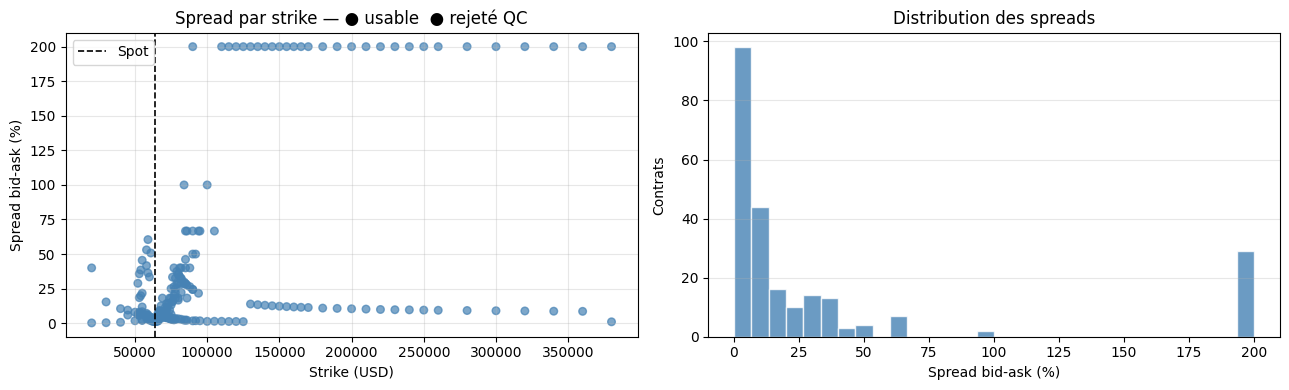

In [120]:
# %% Plot : couverture des quotes et distribution des spreads
from algotrading.infra.universe.contracts import parse_instrument_key

strikes_all, spreads_all, is_usable_all = [], [], []
for q in snapshot.options:
    if q.bid is None or q.ask is None:
        continue
    c = parse_instrument_key(q.instrument_key)
    if not isinstance(c, OptionContract):
        continue
    mid = float(q.mid) if q.mid else None
    if mid and mid > 0:
        spread_rel = float(q.ask - q.bid) / mid
        strikes_all.append(float(c.strike))
        spreads_all.append(spread_rel * 100)  # en %
        is_usable_all.append(is_usable_quote(q))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Spread bid-ask par strike
colors = ["steelblue" if u else "salmon" for u in is_usable_all]
ax1.scatter(strikes_all, spreads_all, c=colors, alpha=0.7, s=30)
ax1.axvline(float(snapshot.reference_spot), color="black", lw=1.2, ls="--", label="Spot")
ax1.set(
    xlabel="Strike (USD)",
    ylabel="Spread bid-ask (%)",
    title="Spread par strike — ● usable  ● rejeté QC",
)
ax1.legend()
ax1.grid(alpha=0.3)

# Distribution des spreads
ax2.hist(spreads_all, bins=30, color="steelblue", alpha=0.8, edgecolor="white")
ax2.set(xlabel="Spread bid-ask (%)", ylabel="Contrats", title="Distribution des spreads")
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4 · Courbe forward (parité put-call)

`build_forward_curve` estime le forward implicite par parité put-call, maturity par maturity.
Pour le crypto, le taux de portage absorbe le funding rate du perpetuel plutôt qu'un taux sans
risque + dividende — d'où les bornes larges (`min_rate=-10%`, `max_rate=+60%`).

> **Caveat de lecture.** Aux maturités courtes, le taux implicite `r` est dominé par le bruit
> bid/ask : il peut être non-monotone et changer de signe d'une expiry à l'autre. Ce n'est donc
> pas une « courbe de funding » propre mais un proxy — la même fragilité courte-maturité explique
> les violations calendaires observées plus bas (§6). En mode synthétique (`LIVE_DATA=False`), le
> forward est posé à `spot` (r≈0) : l'étape forward y est volontairement dégénérée.

In [121]:
# %% Courbe forward
fwd_params = ForwardParams(
    max_candidate_count=12,
    max_robust_zscore=3.5,
    epsilon=Decimal("0.0001"),
    min_candidates=2,
    day_count=DayCountConvention("ACT/365F"),
    min_maturity_years=0.005,  # ~1.8 jours : exclut le near-expiry numeriquement instable
    min_rate=Decimal("-0.10"),  # funding negatif possible en bear market
    max_rate=Decimal("0.60"),  # pic de funding en bull market
    comfortable_candidate_count=3,
)

# Forward sur le snapshot FILTRE (quotes usables) -> parite put-call propre.
forward_curve = build_forward_curve(clean, fwd_params)

print(f"Maturites avec forward accepte : {len(forward_curve.maturities)}")
for m in forward_curve.maturities:
    dte = int(m.maturity_years * 365)
    print(
        f"  {m.expiry}  ({dte:3d}j)  "
        f"F={float(m.forward_price):,.0f}  "
        f"r={float(m.rate) * 100:+.2f}%  "
        f"carry={float(m.implied_carry) * 100:+.2f}%  "
        f"[{m.quality.value}]"
    )

{"ts": "2026-06-04T07:43:41.277827+00:00", "level": "WARNING", "logger": "algotrading.infra.forwards.engine", "message": "skipping maturity 2026-06-12: implied rate -0.2588797537209474 outside [-0.10, 0.60]"}


Maturites avec forward accepte : 2
  2026-06-19  ( 15j)  F=63,966  r=+2.27%  carry=+1.31%  [ok]
  2026-06-26  ( 22j)  F=63,992  r=-1.38%  carry=-2.73%  [ok]


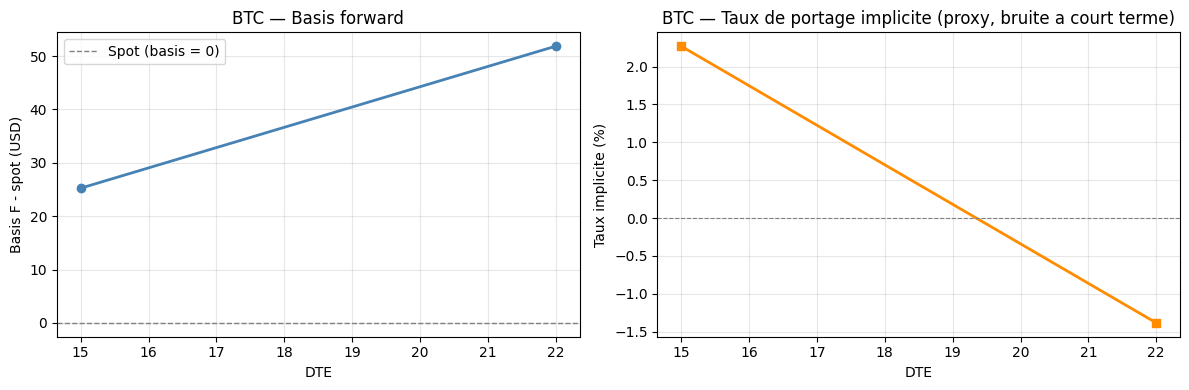

In [122]:
# %% Plot : basis forward (F - spot) + taux implicite vs maturité
if not forward_curve.maturities:
    print("Aucun forward accepté — plot ignoré.")
else:
    spot_ref = float(snapshot.reference_spot)
    fwds = [float(m.forward_price) for m in forward_curve.maturities]
    basis = [f - spot_ref for f in fwds]
    rates = [float(m.rate) * 100 for m in forward_curve.maturities]
    dtes_m = [int(m.maturity_years * 365) for m in forward_curve.maturities]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Basis (F - spot) en USD : le niveau forward seul est visuellement plat vs le spot.
    ax1.plot(dtes_m, basis, "o-", color="steelblue", lw=2)
    ax1.axhline(0, color="grey", ls="--", lw=1, label="Spot (basis = 0)")
    ax1.set(xlabel="DTE", ylabel="Basis F - spot (USD)", title=f"{CURRENCY} — Basis forward")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(dtes_m, rates, "s-", color="darkorange", lw=2)
    ax2.axhline(0, color="grey", ls="--", lw=0.8)
    ax2.set(
        xlabel="DTE",
        ylabel="Taux implicite (%)",
        title=f"{CURRENCY} — Taux de portage implicite (proxy, bruite a court terme)",
    )
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 5 · Inversion IV — chaîne d'options

`solve_chain` inverse chaque quote usable en volatilité implicite Black-76 (forward-consistent).
Le résultat est un `IvPoint` par option : log-moneyness, variance totale, delta, statut
(`solved` / `unsolved` + raison). Les quotes hors bornes ou près de la valeur intrinsèque
produisent un point explicitement non-résolu — jamais un `NaN` silencieux.

In [123]:
# %% Inversion IV
iv_params = IvParams.from_config(load_config(CONFIGS / "qc.yaml"))

iv_points = solve_chain(clean, forward_curve, iv_params)

n_solved = sum(1 for p in iv_points if p.status == "solved")
n_unsolved = len(iv_points) - n_solved

print(f"IvPoints generes  : {len(iv_points)}")
print(f"  -> solved       : {n_solved}")
print(f"  -> unsolved     : {n_unsolved}")

if n_unsolved:
    reasons: dict[str, int] = {}
    for p in iv_points:
        if p.status != "solved" and p.failure_reason:
            reasons[p.failure_reason] = reasons.get(p.failure_reason, 0) + 1
    print("  Raisons echec:", reasons)

IvPoints generes  : 107
  -> solved       : 96
  -> unsolved     : 11
  Raisons echec: {'below_intrinsic': 11}


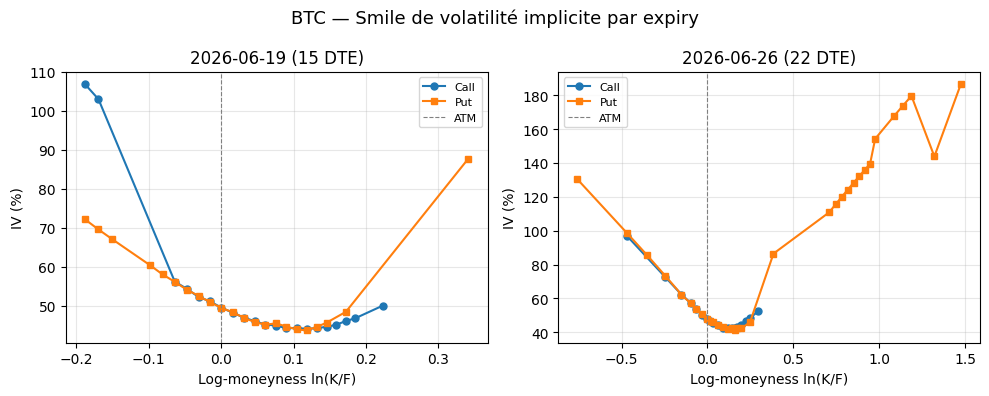

In [124]:
# %% Plot : smile IV par expiry (log-moneyness vs IV)
if not iv_points:
    print("Aucun IvPoint — plot ignoré.")
else:
    solved_pts = [p for p in iv_points if p.status == "solved" and p.implied_vol is not None]

    # Grouper par date d'expiry
    from collections import defaultdict

    by_exp: dict = defaultdict(list)
    for p in solved_pts:
        by_exp[p.expiry_date].append(p)

    fig, axes = plt.subplots(1, len(by_exp), figsize=(5 * len(by_exp), 4), squeeze=False)

    for idx, (exp, pts) in enumerate(sorted(by_exp.items())):
        ax = axes[0][idx]
        dte = (exp - date.today()).days
        calls = sorted(
            [p for p in pts if parse_instrument_key(p.contract_key).right == Right.CALL],
            key=lambda p: p.log_moneyness,
        )
        puts = sorted(
            [p for p in pts if parse_instrument_key(p.contract_key).right == Right.PUT],
            key=lambda p: p.log_moneyness,
        )

        if calls:
            ax.plot(
                [p.log_moneyness for p in calls],
                [p.implied_vol * 100 for p in calls],
                "o-",
                color="C0",
                label="Call",
                ms=5,
            )
        if puts:
            ax.plot(
                [p.log_moneyness for p in puts],
                [p.implied_vol * 100 for p in puts],
                "s-",
                color="C1",
                label="Put",
                ms=5,
            )

        ax.axvline(0, color="grey", ls="--", lw=0.8, label="ATM")
        ax.set(xlabel="Log-moneyness ln(K/F)", ylabel="IV (%)", title=f"{exp} ({dte} DTE)")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle(f"{CURRENCY} — Smile de volatilité implicite par expiry", fontsize=13)
    plt.tight_layout()
    plt.show()

## 6 · Surface SVI

`build_surface` ajuste un modèle SVI (*Stochastic Volatility Inspired*, Gatheral 2004) slice par
slice en minimisant le RMSE en variance totale, puis reconstruit une grille régulière
(log-moneyness × maturité). Les diagnostics calendaires (Eq. 21) vérifient la monotonie
cross-maturité — une violation indiquerait un arbitrage calendaire.

In [125]:
# %% Surface SVI
qc_cfg = load_config(CONFIGS / "qc.yaml")
surface_cfg = SurfaceConfig.from_config(qc_cfg.data["surface_engine"])

# build_surface ne consomme que les points solved ; on filtre explicitement pour la clarte.
# config_hash REEL (sha256 du config resolu) -> la surface trace ses seuils d'origine.
solved_iv = [p for p in iv_points if p.status == "solved"]
surface_result: SurfaceResult = build_surface(
    solved_iv,
    surface_cfg,
    config_hash=qc_cfg.config_hash,
)

print(f"Slices SVI calibrees : {len(surface_result.parameters.slices)}")
print(f"config_hash          : {surface_result.parameters.config_hash[:12]}...")
print()
for sl in surface_result.parameters.slices:
    method = sl.method.upper()
    dte = int(sl.maturity_years * 365)
    rmse = f"RMSE={sl.rmse:.5f}" if sl.rmse is not None else "RMSE=n/a"
    conv = "OK" if sl.converged else "X"
    # Une slice qui tape une borne est lissee mais surajustee : a signaler, pas a croire.
    bounds = f"  bound_hits={sl.bound_hits}" if sl.bound_hits else ""
    flag = "  <- mal conditionnee (borne atteinte)" if sl.bound_hits else ""
    print(f"  {dte:3d}j  [{method:5s}]  n={sl.n_points}  {rmse}  {conv}{bounds}{flag}")

# Violations calendaires (Eq. 21) : variance totale qui DECROIT avec la maturite = arbitrage.
diag = surface_result.diagnostics
print(f"\nViolations calendaires : {len(diag.calendar_violations)}")
if diag.calendar_violations:
    hdr = f"  {'DTE bas->haut':>13}  {'ln(K/F)':>8}  {'var_bas':>9}  {'var_haut':>9}  {'delta':>9}"
    print(hdr)
    for v in diag.calendar_violations:
        d_lo, d_hi = int(v.maturity_low * 365), int(v.maturity_high * 365)
        dv = v.variance_high - v.variance_low
        rng = f"{d_lo}->{d_hi}j"
        print(
            f"  {rng:>13}  {v.log_moneyness:>8.3f}  "
            f"{v.variance_low:>9.5f}  {v.variance_high:>9.5f}  {dv:>+9.5f}"
        )
    print("  (delta<0 => variance totale decroit avec la maturite : breach no-arbitrage)")

Slices SVI calibrees : 2
config_hash          : d6852ebe187a...

   15j  [SVI  ]  n=43  RMSE=0.00464  OK  bound_hits=('a',)  <- mal conditionnee (borne atteinte)
   22j  [SVI  ]  n=53  RMSE=0.01197  OK  bound_hits=('a',)  <- mal conditionnee (borne atteinte)

Violations calendaires : 6
  DTE bas->haut   ln(K/F)    var_bas   var_haut      delta
        15->22j    -0.400    0.05903    0.05198   -0.00705
        15->22j    -0.350    0.05233    0.04731   -0.00502
        15->22j    -0.300    0.04566    0.04265   -0.00301
        15->22j    -0.250    0.03902    0.03801   -0.00101
        15->22j     0.150    0.01039    0.00806   -0.00233
        15->22j     0.200    0.01334    0.01191   -0.00143
  (delta<0 => variance totale decroit avec la maturite : breach no-arbitrage)


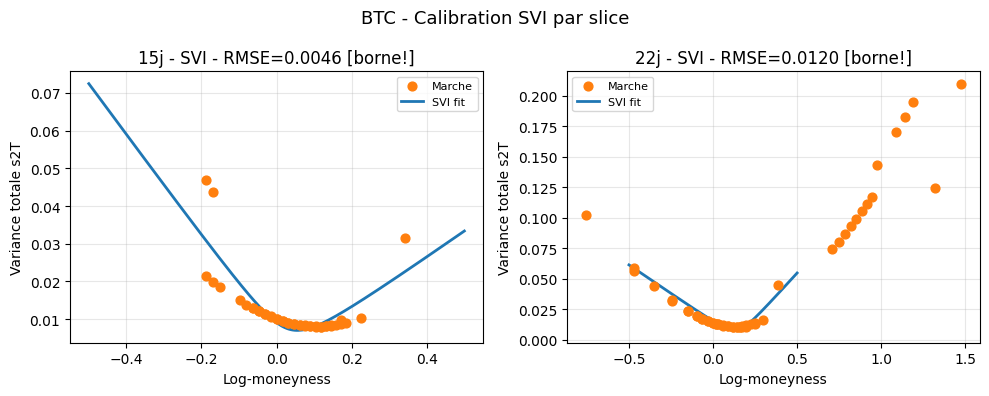

In [126]:
# %% Plot : SVI fit vs points de marche par slice
from algotrading.infra.surfaces.svi import svi_total_variance

slices = surface_result.parameters.slices
raw_pts = surface_result.raw_points

if not slices:
    print("Aucune slice - plot ignore.")
else:
    n_plots = len(slices)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4), squeeze=False)

    for idx, sl in enumerate(slices):
        ax = axes[0][idx]
        dte = int(sl.maturity_years * 365)

        raw = next((r for r in raw_pts if abs(r.maturity_years - sl.maturity_years) < 1e-4), None)
        if raw and raw.log_moneyness:
            ax.scatter(
                raw.log_moneyness, raw.total_variance, s=40, color="C1", label="Marche", zorder=5
            )

        if sl.method == "svi" and sl.params is not None:
            p = sl.params
            k_grid = np.linspace(-0.5, 0.5, 200)
            tv_grid = svi_total_variance(k_grid, a=p.a, b=p.b, rho=p.rho, m=p.m, sigma=p.sigma)
            ax.plot(k_grid, tv_grid, color="C0", lw=2, label="SVI fit")

        # Le titre porte la qualite du fit (RMSE) et signale une slice mal conditionnee.
        rmse_s = f"RMSE={sl.rmse:.4f}" if sl.rmse is not None else ""
        warn = " [borne!]" if sl.bound_hits else ""
        ax.set(
            xlabel="Log-moneyness",
            ylabel="Variance totale s2T",
            title=f"{dte}j - {sl.method.upper()} - {rmse_s}{warn}",
        )
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle(f"{CURRENCY} - Calibration SVI par slice", fontsize=13)
    plt.tight_layout()
    plt.show()

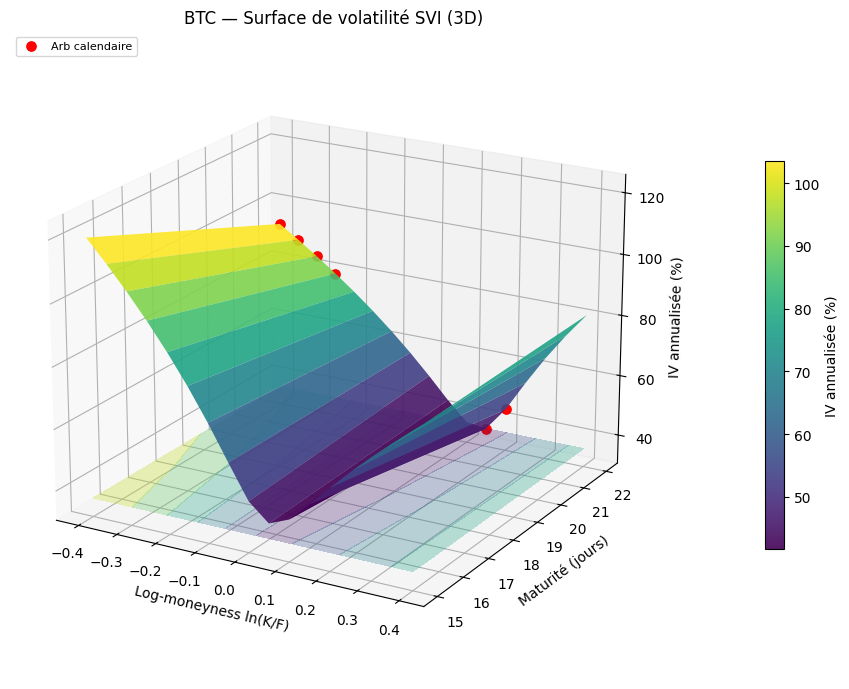

In [127]:
# %% Plot : surface SVI 3D (IV vs log-moneyness × maturité) + violations calendaires
grid = surface_result.grid

if grid is None or not grid.maturity_years:
    print("Grille indisponible — plot ignoré.")
else:
    k_axis = np.array(grid.log_moneyness)
    t_axis = np.array(grid.maturity_years)
    tv = np.array(grid.total_variance)  # shape (n_maturities, n_moneyness)

    # Variance totale → IV annualisée : IV = sqrt(TV / T)
    with np.errstate(divide="ignore", invalid="ignore"):
        iv = np.sqrt(np.maximum(tv, 0) / t_axis[:, None]) * 100
        iv_grid = np.where(t_axis[:, None] > 0, iv, np.nan)

    kk, tt = np.meshgrid(k_axis, t_axis)
    floor = float(np.nanmin(iv_grid))

    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(
        kk,
        tt * 365,
        iv_grid,
        cmap="viridis",
        edgecolor="none",
        antialiased=True,
        alpha=0.9,
    )
    # Contours projetes sur le plancher pour lire le skew / la term-structure.
    ax.contourf(kk, tt * 365, iv_grid, zdir="z", offset=floor, cmap="viridis", alpha=0.3)

    # Marque en rouge les points en violation calendaire (variance totale decroissante).
    viol = surface_result.diagnostics.calendar_violations
    if viol:
        vx = [v.log_moneyness for v in viol]
        vy = [v.maturity_high * 365 for v in viol]
        vz = [np.sqrt(max(v.variance_high, 0.0) / v.maturity_high) * 100 for v in viol]
        ax.scatter(vx, vy, vz, color="red", s=45, depthshade=False, label="Arb calendaire")
        ax.legend(loc="upper left", fontsize=8)

    fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="IV annualisée (%)")
    ax.set(
        xlabel="Log-moneyness ln(K/F)",
        ylabel="Maturité (jours)",
        zlabel="IV annualisée (%)",
        title=f"{CURRENCY} — Surface de volatilité SVI (3D)",
    )
    ax.view_init(elev=20, azim=-60)
    plt.tight_layout()
    plt.show()

## 7 · Pricing & Greeks sur la chaîne

On re-price chaque option de la première expiry avec la volatilité **échantillonnée sur la surface
SVI calibrée** (`grid.total_variance_at(maturity, k)` → IV = √(variance totale / T)) — et non l'IV
brute par quote. Ceci ferme la boucle : la surface lissée et sans-arbitrage est ce qui sert
réellement à pricer, et cela donne une IV unique par strike (call et put au même K partagent la
même vol). Les Greeks analytiques (Δ, Γ, Vega, Θ) sont ceux d'un pricer européen Black-76.

In [128]:
# %% Pricing + Greeks : première expiry (vol echantillonnee sur la surface SVI)
pricing_params = PricingParams.from_config(load_config(CONFIGS / "pricing.yaml"))

# Sélectionner la première expiry avec des IvPoints solved
solved_by_exp: dict = defaultdict(list)
for p in iv_points:
    if p.status == "solved" and p.implied_vol is not None:
        solved_by_exp[p.expiry_date].append(p)

_grid = surface_result.grid  # surface SVI -> source de la vol de pricing


def _surface_vol(k: float, t_yr: float, fallback: float) -> float:
    """IV lue sur la surface SVI a (log-moneyness, maturite) ; fallback = IV brute par quote."""
    if _grid is None or t_yr <= 0:
        return fallback
    tv = _grid.total_variance_at(maturity=t_yr, k=k)
    return float(np.sqrt(max(tv, 0.0) / t_yr))


if not solved_by_exp:
    print("Aucun IvPoint solved — pricing impossible.")
else:
    first_exp = sorted(solved_by_exp)[0]
    pts_exp = solved_by_exp[first_exp]
    spot = float(snapshot.reference_spot)

    # Forward pour cette expiry
    fwd_mat = next((m for m in forward_curve.maturities if m.expiry == first_exp), None)
    forward = float(fwd_mat.forward_price) if fwd_mat else spot
    rate = float(fwd_mat.rate) if fwd_mat else 0.0
    carry = float(fwd_mat.implied_carry) if fwd_mat else 0.0
    T = pts_exp[0].maturity_years

    pricing_inputs: dict[str, PricingInput] = {}
    pricing_vol: dict[str, float] = {}
    for p in pts_exp:
        c = parse_instrument_key(p.contract_key)
        if not isinstance(c, OptionContract):
            continue
        vol = _surface_vol(p.log_moneyness, T, p.implied_vol)
        pricing_vol[p.contract_key] = vol
        pricing_inputs[p.contract_key] = PricingInput(
            spot=spot,
            strike=float(c.strike),
            maturity=T,
            vol=vol,
            rate=rate,
            carry=carry,
            is_call=(c.right == Right.CALL),
            multiplier=c.multiplier,
            style=OptionStyle.EUROPEAN,
        )

    results = {key: price(inp, pricing_params) for key, inp in pricing_inputs.items()}

    print(f"Expiry pricée : {first_exp} ({int(T * 365)}j)")
    print(f"Spot={spot:,.0f}  Forward={forward:,.0f}  T={T:.4f}y  (vol depuis surface SVI)")
    print(f"Options pricées : {len(results)}")

    # Aperçu des 3 options les plus proches ATM
    atm_pts = sorted(pts_exp, key=lambda p: abs(p.log_moneyness))[:3]
    print("\nATM proches :")
    for p in atm_pts:
        c = parse_instrument_key(p.contract_key)
        r = results.get(p.contract_key)
        if r:
            print(
                f"  K={float(c.strike):>8,.0f}  IV={pricing_vol[p.contract_key] * 100:.1f}%  "
                f"P=${r.price:>8.2f}  Δ={r.delta:+.3f}  Γ={r.gamma:.6f}  "
                f"Vega=${r.dollar_vega:.2f}"
            )

Expiry pricée : 2026-06-19 (15j)
Spot=63,940  Forward=63,966  T=0.0411y  (vol depuis surface SVI)
Options pricées : 43

ATM proches :
  K=  64,000  IV=46.9%  P=$ 2409.05  Δ=+0.516  Γ=0.000065  Vega=$5163.79
  K=  64,000  IV=46.9%  P=$ 2443.44  Δ=-0.483  Γ=0.000065  Vega=$5163.79
  K=  63,000  IV=50.6%  P=$ 3104.32  Δ=+0.579  Γ=0.000060  Vega=$5066.40


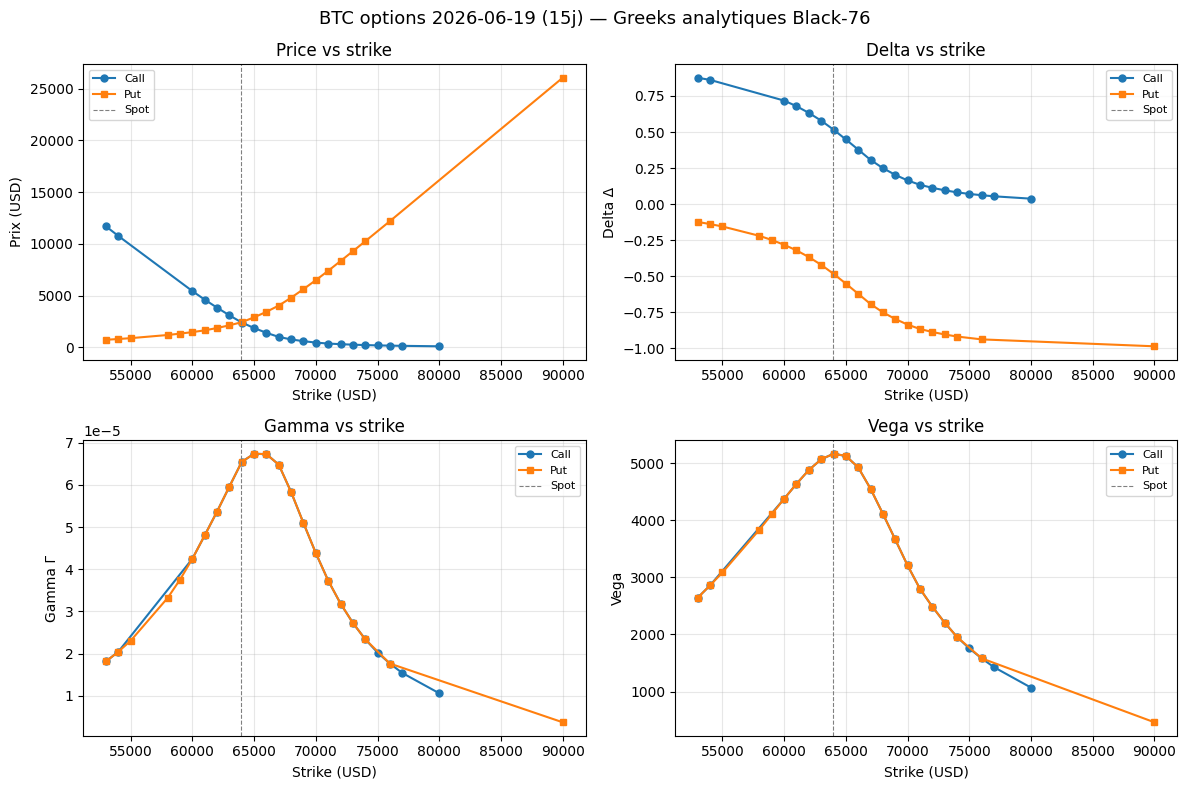

In [129]:
# %% Plot : Δ, Γ, Vega, Prix vs strike — calls et puts séparés
if not solved_by_exp:
    print("Pas de données — plot ignoré.")
else:
    calls_data = [
        (parse_instrument_key(k), results[k])
        for k in results
        if isinstance(parse_instrument_key(k), OptionContract)
        and parse_instrument_key(k).right == Right.CALL
    ]
    puts_data = [
        (parse_instrument_key(k), results[k])
        for k in results
        if isinstance(parse_instrument_key(k), OptionContract)
        and parse_instrument_key(k).right == Right.PUT
    ]

    calls_data.sort(key=lambda x: float(x[0].strike))
    puts_data.sort(key=lambda x: float(x[0].strike))

    def _extract(data, attr):
        return [float(c.strike) for c, _ in data], [getattr(r, attr) for _, r in data]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    attrs = ["price", "delta", "gamma", "vega"]
    ylabels = ["Prix (USD)", "Delta Δ", "Gamma Γ", "Vega"]

    for ax, attr, ylabel in zip(axes.flat, attrs, ylabels, strict=False):
        if calls_data:
            xs, ys = _extract(calls_data, attr)
            ax.plot(xs, ys, "o-", color="C0", label="Call", ms=5)
        if puts_data:
            xs, ys = _extract(puts_data, attr)
            ax.plot(xs, ys, "s-", color="C1", label="Put", ms=5)
        ax.axvline(spot, color="grey", ls="--", lw=0.8, label="Spot")
        ax.set(xlabel="Strike (USD)", ylabel=ylabel, title=f"{attr.capitalize()} vs strike")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    dte_str = int(T * 365)
    fig.suptitle(
        f"{CURRENCY} options {first_exp} ({dte_str}j) — Greeks analytiques Black-76", fontsize=13
    )
    plt.tight_layout()
    plt.show()

## 8 · Risque — portefeuille fictif

On construit un **straddle ATM fictif** (long 1 call ATM + long 1 put ATM, même expiry), puis on
calcule le risque extensif ligne par ligne (`compute_risk_lines`) et agrégé par expiry
(`aggregate_risk`). Les Greeks **extensifs** (= quantité × multiplicateur × Greek unitaire)
s'additionnent exactement sur les lignes — la propriété garantit que l'aggrégat du portefeuille
est la somme des lignes.

In [130]:
# %% Risque - straddle ATM fictif (meme strike pour les deux jambes)
risk_lines: list = []
agg = None
positions = None
atm_call_key = atm_put_key = None

if not solved_by_exp or not results:
    print("Pas de donnees pricees - risk ignore.")
else:
    # ATM = strike de plus petit |ln(K/F)|, puis call ET put a CE meme strike.
    # Un vrai straddle impose un strike unique ; deux strikes != => strangle mal etiquete.
    lm = {p.contract_key: p.log_moneyness for p in solved_by_exp[first_exp]}
    atm_key = min(results, key=lambda k: abs(lm.get(k, 999.0)))
    atm_strike = parse_instrument_key(atm_key).strike

    def _leg(right: Right) -> str | None:
        for k in results:
            c = parse_instrument_key(k)
            if c.right == right and c.strike == atm_strike:
                return k
        return None

    atm_call_key = _leg(Right.CALL)
    atm_put_key = _leg(Right.PUT)

    if not atm_call_key or not atm_put_key:
        print("Call ou put ATM introuvable au meme strike - risk ignore.")
    else:
        print(f"Strike ATM : K={float(atm_strike):,.0f}  (call et put au meme strike)")

        positions = PositionSet(
            positions=(
                Position(instrument_key=atm_call_key, quantity=Decimal("1")),
                Position(instrument_key=atm_put_key, quantity=Decimal("1")),
            ),
            source="notebook-demo",
            source_ts=AS_OF,
        )
        analytics = {
            key: InstrumentAnalytics(
                pricing=results[key],
                multiplier=parse_instrument_key(key).multiplier,
            )
            for key in (atm_call_key, atm_put_key)
        }

        risk_lines = compute_risk_lines(positions, analytics)
        agg = aggregate_risk(risk_lines, by_underlying)[0]  # un seul groupe : BTC

        # Theta : l'unite vient de la config (pricing.yaml). On ne hardcode PAS "/j".
        theta_unit = pricing_params.theta_unit
        theta_suffix = "/an" if theta_unit == "year" else "/j"
        theta_per_day = agg.theta / 365.0 if theta_unit == "year" else agg.theta

        print("\n--- Risque ligne par ligne ---")
        for line in risk_lines:
            c = parse_instrument_key(line.instrument_key)
            print(
                f"  {c.right.value} K={float(c.strike):>8,.0f}  "
                f"Val=${line.value:>10.2f}  D={line.delta:+.4f}  "
                f"G={line.gamma:.6f}  Vega=${line.dollar_vega:.2f}  "
                f"T=${line.theta:.2f}{theta_suffix}"
            )

        print("\n--- Portefeuille agrege (straddle ATM) ---")
        print(f"  Valeur totale : ${agg.value:>12.2f}")
        print(f"  Delta         : {agg.delta:>+12.4f}  (proche 0 : straddle ATM, meme IV surface)")
        print(f"  Gamma         : {agg.gamma:>+12.6f}")
        print(f"  Vega ($)      : ${agg.dollar_vega:>+11.2f}")
        print(f"  Theta ($)     : ${agg.theta:>+11.2f}{theta_suffix}  (convention: {theta_unit})")
        print(f"                  ~= ${theta_per_day:>+11.2f}/j de decay journalier")

Strike ATM : K=64,000  (call et put au meme strike)

--- Risque ligne par ligne ---
  C K=  64,000  Val=$   2409.05  D=+0.5164  G=0.000065  Vega=$5163.79  T=$-29758.50/an
  P K=  64,000  Val=$   2443.44  D=-0.4830  G=0.000065  Vega=$5163.79  T=$-29144.04/an

--- Portefeuille agrege (straddle ATM) ---
  Valeur totale : $     4852.49
  Delta         :      +0.0334  (proche 0 : straddle ATM, meme IV surface)
  Gamma         :    +0.000131
  Vega ($)      : $  +10327.58
  Theta ($)     : $  -58902.54/an  (convention: year)
                  ~= $    -161.38/j de decay journalier


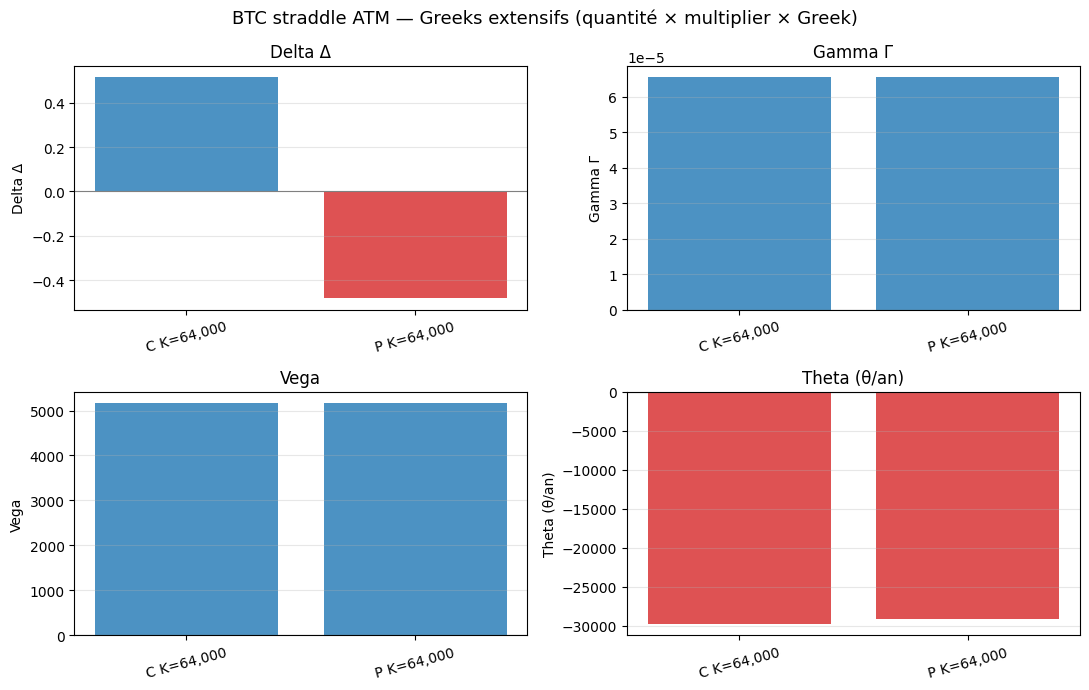

In [131]:
# %% Plot : Greeks du straddle barre par barre
if not solved_by_exp or not results or not risk_lines:
    print("Pas de données risk — plot ignoré.")
else:
    greeks = ["delta", "gamma", "vega", "theta"]
    labels_greek = ["Delta Δ", "Gamma Γ", "Vega", f"Theta (θ{theta_suffix})"]
    labels_legs = []
    greek_vals = {g: [] for g in greeks}

    for line in risk_lines:
        c = parse_instrument_key(line.instrument_key)
        labels_legs.append(f"{c.right.value} K={float(c.strike):,.0f}")
        for g in greeks:
            greek_vals[g].append(getattr(line, g))

    x = np.arange(len(labels_legs))
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))

    for ax, greek, label in zip(axes.flat, greeks, labels_greek, strict=False):
        vals = greek_vals[greek]
        bars = ax.bar(x, vals, color=["C0" if v >= 0 else "C3" for v in vals], alpha=0.8)
        ax.axhline(0, color="grey", lw=0.8)
        ax.set(xticks=x, xticklabels=labels_legs, ylabel=label, title=label)
        ax.tick_params(axis="x", rotation=15)
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle(
        f"{CURRENCY} straddle ATM — Greeks extensifs (quantité × multiplier × Greek)", fontsize=13
    )
    plt.tight_layout()
    plt.show()

## 9 · Scénarios de stress

`run_grid` re-price le portefeuille sous chaque scénario du `ScenarioGrid` (choc spot relatif + choc
vol absolu + roll temporel). Deux estimations par scénario :

- **Full PnL** — re-pricing complet (source de vérité)
- **Local PnL** — approximation Eq. 19 par développement en Greeks (Δ·dS + ½Γ·dS² + Vega·dσ + Θ·dt)

L'écart full/local diagnostique les non-linéarités importantes (utile pour les positions fortement
gamma ou vega).

In [132]:
# %% Scénarios de stress
if not solved_by_exp or not results or not risk_lines:
    print("Pas de données pricées — scénarios ignorés.")
else:
    # Grille de scénarios élargie pour le BTC (vol crypto >> actions)
    scenario_grid = ScenarioGrid(
        scenarios=(
            Scenario(
                name="spot_up_10", family="spot", spot_shock=0.10, vol_shock=0.00, time_shock_days=0
            ),
            Scenario(
                name="spot_up_20", family="spot", spot_shock=0.20, vol_shock=0.00, time_shock_days=0
            ),
            Scenario(
                name="spot_down_10",
                family="spot",
                spot_shock=-0.10,
                vol_shock=0.00,
                time_shock_days=0,
            ),
            Scenario(
                name="spot_down_20",
                family="spot",
                spot_shock=-0.20,
                vol_shock=0.00,
                time_shock_days=0,
            ),
            Scenario(
                name="vol_up_10pt", family="vol", spot_shock=0.00, vol_shock=0.10, time_shock_days=0
            ),
            Scenario(
                name="vol_down_10pt",
                family="vol",
                spot_shock=0.00,
                vol_shock=-0.10,
                time_shock_days=0,
            ),
            Scenario(
                name="crash_down20_vol30",
                family="crash",
                spot_shock=-0.20,
                vol_shock=0.30,
                time_shock_days=0,
            ),
            Scenario(
                name="rally_up20_vol_down",
                family="rally",
                spot_shock=0.20,
                vol_shock=-0.10,
                time_shock_days=0,
            ),
            Scenario(
                name="roll_1d", family="time", spot_shock=0.00, vol_shock=0.00, time_shock_days=1
            ),
            Scenario(
                name="roll_7d", family="time", spot_shock=0.00, vol_shock=0.00, time_shock_days=7
            ),
        ),
        version="notebook-btc-v1",
    )

    # états de pricing indexés par instrument_key
    states = {
        key: pricing_inputs[key] for key in (atm_call_key, atm_put_key) if key in pricing_inputs
    }

    scenario_results = run_grid(positions, states, pricing_params, scenario_grid)

    print(f"Scénarios exécutés : {len(scenario_results)}\n")
    print(f"{'Scénario':<26} {'Full PnL':>12} {'Local PnL':>12} {'Δ (full-local)':>15}")
    print("-" * 68)
    for r in scenario_results:
        diff = r.full_pnl - r.local_pnl
        print(f"  {r.scenario:<24} ${r.full_pnl:>+10.2f}  ${r.local_pnl:>+10.2f}  ${diff:>+12.2f}")

Scénarios exécutés : 10

Scénario                       Full PnL    Local PnL  Δ (full-local)
--------------------------------------------------------------------
  spot_up_10               $  +2574.79  $  +2890.13  $     -315.34
  spot_up_20               $  +8037.75  $ +11133.01  $    -3095.26
  spot_down_10             $  +2344.38  $  +2462.61  $     -118.23
  spot_down_20             $  +7997.43  $ +10277.97  $    -2280.54
  vol_up_10pt              $  +1032.49  $  +1032.76  $       -0.26
  vol_down_10pt            $  -1032.99  $  -1032.76  $       -0.23
  crash_down20_vol30       $  +8568.48  $ +13376.24  $    -4807.76
  rally_up20_vol_down      $  +7920.61  $ +10100.25  $    -2179.65
  roll_1d                  $   -164.18  $   -161.38  $       -2.80
  roll_7d                  $  -1306.76  $  -1129.64  $     -177.12


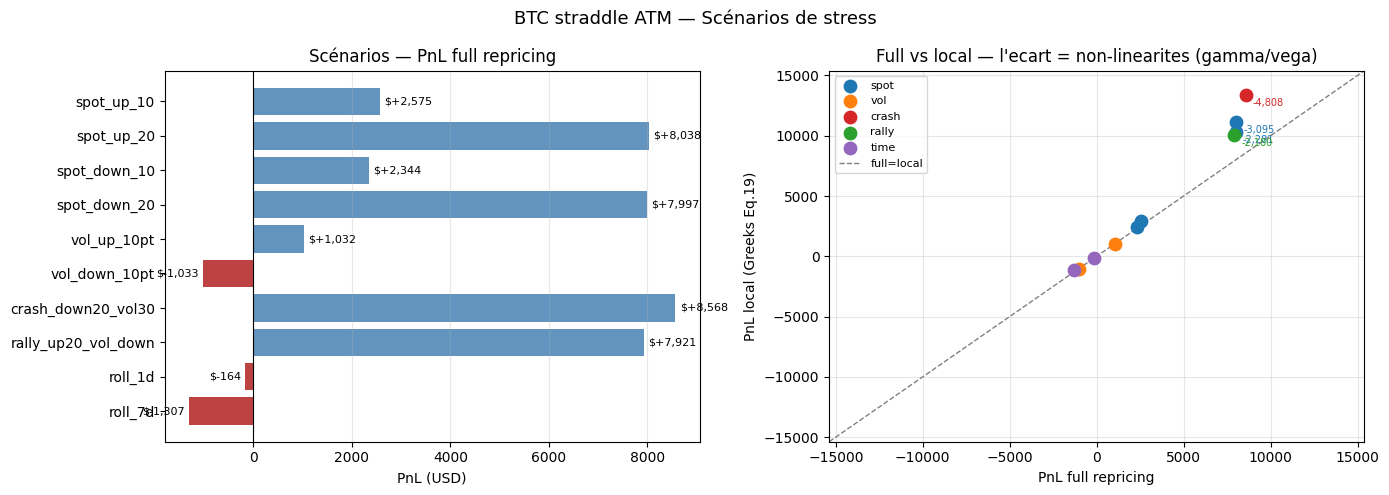

In [133]:
# %% Plot : heatmap PnL full + comparaison full/local par scénario
if not solved_by_exp or not results or not risk_lines:
    print("Pas de données — plot ignoré.")
else:
    names = [r.scenario for r in scenario_results]
    full = np.array([r.full_pnl for r in scenario_results])
    local = np.array([r.local_pnl for r in scenario_results])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ── Barres full PnL ────────────────────────────────────────────────────
    colors = ["steelblue" if v >= 0 else "firebrick" for v in full]
    bars = ax1.barh(names, full, color=colors, alpha=0.85)
    ax1.axvline(0, color="black", lw=0.8)
    ax1.set(xlabel="PnL (USD)", title="Scénarios — PnL full repricing")
    ax1.grid(axis="x", alpha=0.3)
    ax1.invert_yaxis()

    # Annotations valeurs
    for bar, val in zip(bars, full, strict=False):
        ax1.text(
            val + (max(abs(full)) * 0.01 if val >= 0 else -max(abs(full)) * 0.01),
            bar.get_y() + bar.get_height() / 2,
            f"${val:+,.0f}",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=8,
        )

    # ── Scatter full vs local ──────────────────────────────────────────────
    family_colors = {"spot": "C0", "vol": "C1", "crash": "C3", "rally": "C2", "time": "C4"}
    plotted_families = set()
    for r in scenario_results:
        col = family_colors.get(r.family, "grey")
        label = r.family if r.family not in plotted_families else None
        ax2.scatter(r.full_pnl, r.local_pnl, color=col, s=80, label=label, zorder=5)
        gap = r.full_pnl - r.local_pnl
        if abs(gap) > max(abs(full)) * 0.05:  # n'annote que les ecarts significatifs
            ax2.annotate(
                f"{gap:+,.0f}",
                (r.full_pnl, r.local_pnl),
                textcoords="offset points",
                xytext=(5, -8),
                fontsize=7,
                color=col,
            )
        plotted_families.add(r.family)

    # Diagonale full = local : l'ecart vertical = erreur du DL Greeks (Eq.19) sur gros chocs.
    lim = max(abs(np.concatenate([full, local]))) * 1.15
    ax2.plot([-lim, lim], [-lim, lim], "--", color="grey", lw=1, label="full=local")
    ax2.set(
        xlabel="PnL full repricing",
        ylabel="PnL local (Greeks Eq.19)",
        title="Full vs local — l'ecart = non-linearites (gamma/vega)",
        xlim=(-lim, lim),
        ylim=(-lim, lim),
    )
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

    fig.suptitle(f"{CURRENCY} straddle ATM — Scénarios de stress", fontsize=13)
    plt.tight_layout()
    plt.show()

## Récapitulatif de la pile

| Étape | Module | Entrée → Sortie |
|-------|--------|-----------------|
| 1 Connexion | `infra_deribit.connectivity` | REST → `index_price` |
| 2 Discovery | `infra_deribit.collectors.deribit_discovery` | REST → `list[OptionContract]` |
| 3 Snapshot | `infra.snapshots` | `list[RawMarketEvent]` → `MarketStateSnapshot` |
| 4 Forwards | `infra.forwards` | snapshot → `ForwardCurve` (parité put-call) |
| 5 IV chain | `infra.iv` | snapshot + curve → `list[IvPoint]` |
| 6 Surface SVI | `infra.surfaces` | IvPoints → `SurfaceResult` (slices + grille) |
| 7 Pricing | `infra.pricing` | `PricingInput` → `PricingResult` (prix + Greeks) |
| 8 Risk | `infra.risk` | positions + analytics → `RiskLine[]` + agrégats |
| 9 Scénarios | `infra.risk.scenarios` | positions + états → `ScenarioResult[]` |

**Propriétés clés :** déterminisme (mêmes inputs → même output), provenance sur chaque dérivé
(le `threshold_version` du QC (§3) et le `config_hash` de la surface (§6) sont imprimés et tracent
chaque sortie jusqu'aux seuils exacts qui l'ont produite), fallback explicitement labellisé,
aucune logique métier dans ce notebook.